# analysis.cooccurrence-habitat

In this notebook, we aim to understand:
- how cooccurrences are distributed across sites
- how cooccurrences could be related with site species richness

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from daforfer import DaforferDB
import matplotlib.pyplot as plt
import networkx as nx
plt.rcParams['svg.fonttype'] = 'none'
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
si = DaforferDB(conf['si'])
si.toc()

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


┌──────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│   name   │                                                        description                                                        │
│ varchar  │                                                          varchar                                                          │
├──────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ TableS1  │ Table S1: Library sites and context                                                                                       │
│ TableS2  │ This table summarizes most of the information of our detected OTUs, including host_range, site_range, habitat_range, etc. │
│ TableS3  │ Site-level diversity and number of cooccurring virus-bacteria                                                             │
│ TableS4  │ Habitat-level diversity and 

## Load data

In [2]:
alpha_diversity = db.conn.sql('SELECT * FROM D_Site_level_div').df()

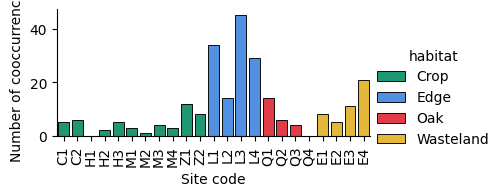

In [3]:
g = sns.catplot(alpha_diversity, x='site', y='total_cooccurrences', height=2.0, aspect=2.0, kind='bar', hue='habitat', palette=conf['habitat_palette'], edgecolor='black', linewidth=0.65)
# g.axes[0, 0].set_yscale('log')
g.set_ylabels("Number of cooccurrences")
g.set_xlabels("Site code")
g.set_xticklabels(rotation=90)
g.savefig("figures/barplot.species-richness.colbyhabitat.svg")

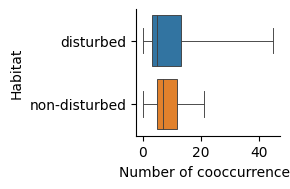

In [4]:
g = sns.catplot(alpha_diversity, y='disturbed', x='total_cooccurrences', height=2.0, aspect=1.5, hue='disturbed', linewidth=0.65, kind='box', whis=1000)
# g.axes[0, 0].set_yscale('log')
g.set_xlabels("Number of cooccurrences")
g.set_ylabels("Habitat")
# g.set_xticklabels(rotation=90)
# g.savefig("figures/barplot.species-richness.colbyhabitat.svg")

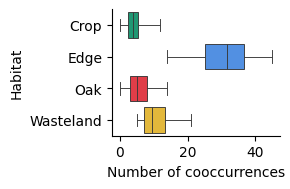

In [5]:
g = sns.catplot(alpha_diversity, y='habitat', x='total_cooccurrences', height=2.0, aspect=1.5, hue='habitat', palette=conf['habitat_palette'], linewidth=0.65, kind='box', whis=1000)
# g.axes[0, 0].set_yscale('log')
g.set_xlabels("Number of cooccurrences")
g.set_ylabels("Habitat")
# g.set_xticklabels(rotation=90)
# g.savefig("figures/barplot.species-richness.colbyhabitat.svg")

In [6]:
stats.kruskal(
    alpha_diversity.query('habitat == "Crop"')['total_cooccurrences'],
    alpha_diversity.query('habitat == "Edge"')['total_cooccurrences'],
    alpha_diversity.query('habitat == "Oak"')['total_cooccurrences'],
    alpha_diversity.query('habitat == "Wasteland"')['total_cooccurrences'],
)

KruskalResult(statistic=11.818023833167826, pvalue=0.008033255691626467)

In [7]:
stats.mannwhitneyu(
    alpha_diversity.query('habitat == "Crop" or habitat == "Edge"')['total_cooccurrences'],
    alpha_diversity.query('habitat == "Oak" or habitat == "Wasteland"')['total_cooccurrences']
)

MannwhitneyuResult(statistic=55.5, pvalue=0.7957593834324872)

### Post-hoc analysis

In [8]:
post_hoc_stats = []

for h1 in ['Crop', 'Edge', 'Wasteland', 'Oak']:
    for h2 in ['Crop', 'Edge', 'Wasteland', 'Oak']:
        if h1 != h2:
            kw_h, pval = stats.mannwhitneyu(
                alpha_diversity.query('habitat == "{0}"'.format(h1))['total_cooccurrences'].values,
                alpha_diversity.query('habitat == "{0}"'.format(h2))['total_cooccurrences'].values,
            )
            significative = pval < 0.05
            post_hoc_stats.append(
                {'group_1': h1, 'group_2': h2, 'U': kw_h, 'p-val': pval, 'sign': significative}
            )
post_hoc_stats = pd.DataFrame.from_records(post_hoc_stats)

db.save_dataframe(
    df=post_hoc_stats, table_name="T_coocByHabitat",
    description="Post-Hoc Mann Whitney U analysis on number of cooccurrennt pairs by habitat"
)

si.save_dataframe(
    df=post_hoc_stats, table_name="TableS7",
    description="Mann-Whitney U post-hoc test on site-diversity by habitat"
)

post_hoc_stats

Saved T_coocByHabitat to db.2025-10-27
Saved TableS7 to si.2025-10-27


,group_1,group_2,U,p-val,sign
0,Crop,Edge,0.0,0.004923,True
1,Crop,Wasteland,6.5,0.048959,True
2,Crop,Oak,18.5,0.693998,False
3,Edge,Crop,44.0,0.004923,True
4,Edge,Wasteland,15.0,0.057143,False
5,Edge,Oak,15.5,0.042066,True
6,Wasteland,Crop,37.5,0.048959,True
7,Wasteland,Edge,1.0,0.057143,False
8,Wasteland,Oak,12.0,0.342857,False
9,Oak,Crop,25.5,0.693998,False


## Correlation between site-alpha-diversity and site-number of cooccurrences

In [9]:
# alpha_diversity = pd.read_csv("output/diversity.all.csv", sep=";")
# alpha_diversity = db.conn.sql('SELECT * FROM D_ADAllOrganismsSite').df().drop(columns=['disturbed'])
# alpha_diversity = pd.merge(alpha_diversity, site_cooccurrences, on=['site', 'habitat'])
# db.save_dataframe(
#     alpha_diversity, table_name="Alpha_diversity_bysite_cooccurrences",
#     description="Alpha diveristy and cooccurrences by site"
# )
# alpha_diversity

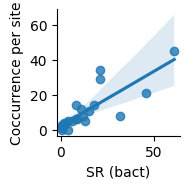

In [10]:
g = sns.lmplot(alpha_diversity, x='species_richness_bact', y='total_cooccurrences', height=2.0)
g.set_xlabels("SR (bact)")
g.set_ylabels("Coccurrence per site")

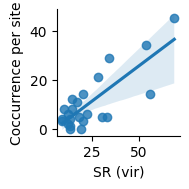

In [11]:
g = sns.lmplot(alpha_diversity, x='species_richness_vir', y='total_cooccurrences', height=2.0)
g.set_xlabels("SR (vir)")
g.set_ylabels("Coccurrence per site")

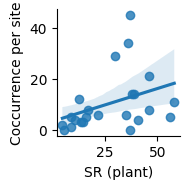

In [12]:
g = sns.lmplot(alpha_diversity, x='species_richness_plant', y='total_cooccurrences', height=2.0)
g.set_xlabels("SR (plant)")
g.set_ylabels("Coccurrence per site")

In [13]:
def reg2dict(x, level):

    return {"level": level, "p-value": x.pvalue, "r-value": x.rvalue, "slope": x.slope}
regression_tests = pd.DataFrame.from_records([
    reg2dict(stats.linregress(alpha_diversity['species_richness_bact'], alpha_diversity['total_cooccurrences']), "Bact"),
    reg2dict(stats.linregress(alpha_diversity['species_richness_vir'], alpha_diversity['total_cooccurrences']), "Virus"),
    reg2dict(stats.linregress(alpha_diversity['species_richness_plant'], alpha_diversity['total_cooccurrences']), "Plant")
])

db.save_dataframe(
    regression_tests, table_name='T_coocDivBySite',
    description='Correlation tests between species richness and number of coocurrences detected at each site'
)
regression_tests

Saved T_coocDivBySite to db.2025-10-27


,level,p-value,r-value,slope
0,Bact,0.000002,0.815848,0.619368
1,Virus,0.000004,0.802639,0.571133
2,Plant,0.086325,0.365513,0.257978


In [14]:
db.conn.close()
si.conn.close()